In [1]:
import shap
import tensorflow as tf
import joblib
import numpy as np
import pandas as pd
import time

model_b = tf.keras.models.load_model("../src/models/saved/model_b_yield_prediction.keras")
scaler_b = joblib.load("../src/models/saved/scaler_b.pkl")
model_b_cols = joblib.load("../src/models/saved/model_b_columns.pkl")

df_b = pd.read_csv("../data/processed/model_b_training_data.csv")
df_b_encoded = pd.get_dummies(df_b, columns=['state_name', 'crop', 'season'], drop_first=True)
df_b_encoded = df_b_encoded.reindex(columns=model_b_cols + ['yield_kg_per_ha'], fill_value=0)

X_b = df_b_encoded[model_b_cols].astype(float)
X_b_scaled = scaler_b.transform(X_b)

background_b = X_b_scaled[np.random.choice(X_b_scaled.shape[0], 100, replace=False)]
explainer_b = shap.KernelExplainer(model_b.predict, background_b)
print("Explainer created")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Explainer created


In [2]:
sample_size = 10
X_sample_b = X_b_scaled[:sample_size]

start = time.time()
shap_values_b = explainer_b.shap_values(X_sample_b, nsamples=100)
elapsed = time.time() - start

print(f"Time taken: {elapsed:.1f} seconds for {sample_size} samples")
print("Shape:", shap_values_b.shape)

  0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Time taken: 13.6 seconds for 10 samples
Shape: (10, 29, 1)


In [3]:
sample_size = 100
X_sample_b = X_b_scaled[:sample_size]

start = time.time()
shap_values_b = explainer_b.shap_values(X_sample_b, nsamples=100)
elapsed = time.time() - start

print(f"Time taken: {elapsed:.1f} seconds for {sample_size} samples")
print("Shape:", shap_values_b.shape)

  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
313/313 ━━━━━━

In [4]:
global_importance_b = np.abs(shap_values_b[:,:,0]).mean(axis=0)

importance_df_b = pd.DataFrame({
    'feature': model_b_cols,
    'importance': global_importance_b
}).sort_values('importance', ascending=False)

print(importance_df_b.head(15))

                      feature  importance
8     state_name_Chhattisgarh  830.015553
26                 crop_maize  279.348607
0                     area_ha  222.575987
25                crop_cotton  161.329956
28                season_Rabi   97.770101
27                  crop_rice   91.774816
2                humidity_pct   34.314111
6            state_name_Assam   30.702793
15  state_name_Madhya Pradesh   23.823251
22   state_name_Uttar Pradesh   21.836040
1               temperature_c   19.000240
5   solar_radiation_mj_m2_day   16.583892
4              wind_speed_m_s   14.524734
24     state_name_West Bengal   14.364752
16     state_name_Maharashtra   13.785372


In [5]:
print(df_b.head(100)['state_name'].value_counts())

state_name
Chhattisgarh    100
Name: count, dtype: int64


In [6]:
np.random.seed(42)
random_idx = np.random.choice(X_b_scaled.shape[0], 100, replace=False)
X_sample_b_random = X_b_scaled[random_idx]

start = time.time()
shap_values_b_random = explainer_b.shap_values(X_sample_b_random, nsamples=100)
elapsed = time.time() - start
print(f"Time taken: {elapsed:.1f} seconds")

global_importance_b_random = np.abs(shap_values_b_random[:,:,0]).mean(axis=0)
importance_df_b_random = pd.DataFrame({
    'feature': model_b_cols,
    'importance': global_importance_b_random
}).sort_values('importance', ascending=False)

print(importance_df_b_random.head(15))

  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
313/313 ━━━━

Saved


C:\Users\Sai Prabhav\AppData\Local\Temp\ipykernel_30712\1808152969.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_b_random[:,:,0], X_b.iloc[random_idx], feature_names=model_b_cols, show=False, max_display=15)


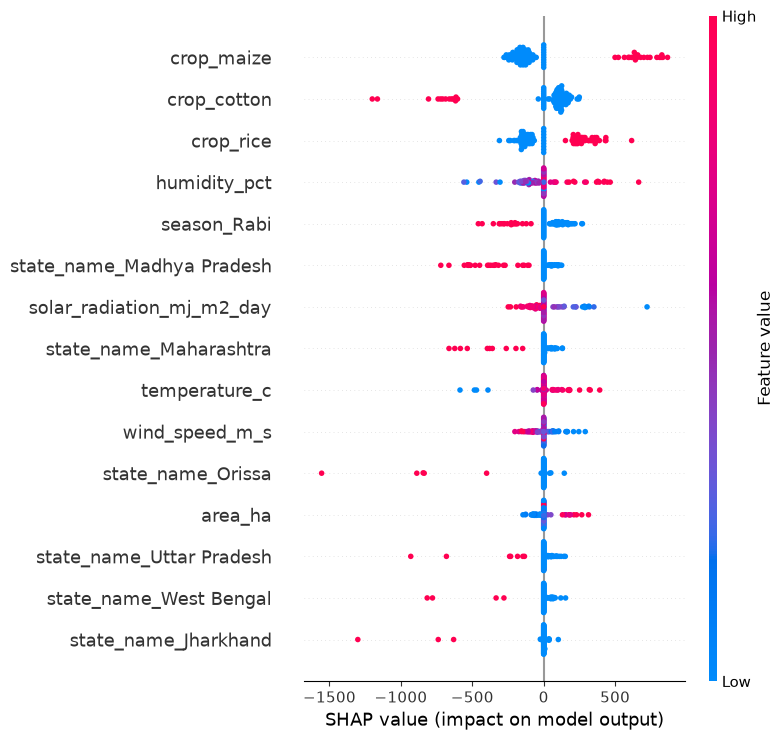

In [7]:
importance_df_b_random.to_csv("../notebooks/model_b_shap_global_importance.csv", index=False)
print("Saved")

import matplotlib.pyplot as plt

shap.summary_plot(shap_values_b_random[:,:,0], X_b.iloc[random_idx], feature_names=model_b_cols, show=False, max_display=15)
plt.tight_layout()
plt.savefig("../notebooks/shap_summary_model_b.png", dpi=150)
plt.show()